# BERT Guardrail

In [1]:
from huggingface_hub import login
from dotenv import load_dotenv
import os

load_dotenv()

hf_token = os.getenv("hf_token")

login(token=hf_token,add_to_git_credential=True)

In [2]:
import numpy as np
import evaluate
from transformers import AutoTokenizer,AutoModelForSequenceClassification,AutoConfig,TrainingArguments, Trainer,TrainerCallback, DataCollatorWithPadding, pipeline, EarlyStoppingCallback
import pandas as pd
import torch
from datasets import Dataset,load_dataset
from sklearn.model_selection import train_test_split
from evaluate import load
#from torch.utils.data import random_split

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
df_review = pd.read_excel("./data/rev_guardrail_r1.xlsx")
df = pd.read_excel('./data/dataset.xlsx')

## Hyperparameter

## Model Configuration

In [5]:
df_review.head()

,Unnamed: 0,text,is_relevant,r1_review_complete,r1_review_extracted,r1_review_extracted_bool,criteria_match
0,0,How do I track my package?,True,"<think>\nOkay, I need to determine if the ques...",True,1.0,True
1,1,What's the weather like today?,False,"<think>\nOkay, let's see. The user wants to kn...",False,0.0,True
2,2,My Spellbots Logistics package is delayed. Wha...,True,"<think>\nOkay, let's see. The question here is...",True,1.0,True
3,3,Can you help me with my math homework?,False,"<think>\nOkay, let's see. The user asked, ""Can...",False,0.0,True
4,4,What are your shipping rates for international...,True,"<think>\nOkay, let's evaluate this question. T...",True,1.0,True


In [6]:
df.head()

,text,is_relevant
0,How do I track my package?,True
1,What's the weather like today?,False
2,My Spellbots Logistics package is delayed. Wha...,True
3,Can you help me with my math homework?,False
4,What are your shipping rates for international...,True


In [7]:
df['is_relevant'].value_counts()

is_relevant
True     1236
False     972
Name: count, dtype: int64

In [8]:
df_review['r1_review_extracted'].value_counts()

r1_review_extracted
True     1265
False     942
Name: count, dtype: int64

In [9]:
df_review['criteria_match'].value_counts()

criteria_match
True     2178
False      30
Name: count, dtype: int64

### Here, I am only taking the data that two models agree on each other. From the look of it, the ratio of True to False label data is approximately 4:3. Moderately balance data.

In [10]:
df_review.loc[df_review["criteria_match"]==True,["is_relevant"]].value_counts()

is_relevant
True           1236
False           942
Name: count, dtype: int64

### Retain the rows that have same criteria matches

In [11]:
final_dataset = df_review[df_review["criteria_match"]==True].copy()

In [12]:
final_dataset.drop(["Unnamed: 0","r1_review_complete","r1_review_extracted","r1_review_extracted_bool","criteria_match"],axis=1,inplace=True)

In [13]:
final_dataset = final_dataset.rename(columns={"is_relevant":"label"})

In [14]:
label_mapping = {False:0,True:1}
final_dataset["label"] = final_dataset["label"].map(label_mapping)

In [15]:
final_dataset.head()

,text,label
0,How do I track my package?,1
1,What's the weather like today?,0
2,My Spellbots Logistics package is delayed. Wha...,1
3,Can you help me with my math homework?,0
4,What are your shipping rates for international...,1


## Setting up Model and Tokenizer

In [16]:
num_labels = final_dataset["label"].nunique()
unique_labels = sorted(final_dataset["label"].unique().tolist())

label2id = {label:i for i, label in enumerate(unique_labels)}
id2label = {i:label for i, label in enumerate(unique_labels)}

## Spliting Data

In [17]:
train_data, test_data = train_test_split(final_dataset,  test_size=0.2,shuffle=True, random_state=24)

# train_size = int(len(final_dataset)*0.8)
# valid_size = len(final_dataset)-train_size


### Implementing Cross Validation

In [18]:
# Convert to Hugging Face Dataset
hf_train_ds = Dataset.from_pandas(train_data,preserve_index=False)
hf_test_ds = Dataset.from_pandas(test_data,preserve_index=False)

In [19]:
hf_train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 1742
})

In [20]:
# Compute number of ideal k folds uisng Sturges's Law
n = len(hf_train_ds)
k_folds = int(1+np.log(n))

# Shuffle indices for randomness
indices = np.arange(n)
np.random.shuffle(indices)

# Split into k folds
# fold_size = n // k_folds
# folds = [indices[i*fold_size : (i+1)*fold_size] for i in range(k_folds)]# (0,217),(217,434)
folds = np.array_split(indices, k_folds)

# Create train/val splits
splits = []
for k in range(k_folds):
    val_idx = folds[k]
    train_idx = np.concatenate([folds[i] for i in range(k_folds) if i != k])

    train_ds = hf_train_ds.select(train_idx.tolist()) # extract subset of data
    val_ds = hf_train_ds.select(val_idx.tolist()) # Create val dataset from train dataset

    splits.append((train_ds, val_ds))


In [21]:
model_id = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)

In [22]:
# Tokenize text to ids
def tokenize_func(batch):

    tokens = tokenizer(batch["text"],
                     padding="longest",
                     #max_length=512,
                     truncation=True)

    return tokens

tokenized_ds = []
for train_ds, val_ds in splits:
    tokenized_train = train_ds.map(tokenize_func, batched=True, remove_columns=["text"])
    tokenized_val = val_ds.map(tokenize_func, batched=True, remove_columns=["text"])
    tokenized_ds.append({"train":tokenized_train,"validation":tokenized_val})
    

Map:   0%|          | 0/1524 [00:00<?, ? examples/s]

Map:   0%|          | 0/218 [00:00<?, ? examples/s]

Map:   0%|          | 0/1524 [00:00<?, ? examples/s]

Map:   0%|          | 0/218 [00:00<?, ? examples/s]

Map:   0%|          | 0/1524 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/218 [00:00<?, ? examples/s]

Map:   0%|          | 0/1525 [00:00<?, ? examples/s]

Map:   0%|          | 0/217 [00:00<?, ? examples/s]

Map:   0%|          | 0/1525 [00:00<?, ? examples/s]

Map:   0%|          | 0/217 [00:00<?, ? examples/s]

In [23]:
len(tokenized_ds)

8

In [24]:
print(tokenized_ds[0]["train"].features)

{'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


## Fine-Tuning classifier head 

In [25]:
# # Freeze all layers except the classifier
# for param in model.bert.parameters():
#     param.requires_grad = False

# # Keep only the classification head trainable
# for param in model.classifier.parameters():
#     param.requires_grad = True

# print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

In [26]:
# Ensure that each batch is dynamically padded to the longest sequence in that batch during training to save memory (instead of padding before runtime)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [27]:
# Load metrics
f1_metric = load("f1")
precision_metric = load("precision")
recall_metric = load("recall")

# Define a custom compute_metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return {
        "f1": f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"],
        "precision": precision_metric.compute(predictions=predictions, references=labels, average="weighted")["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels, average="weighted")["recall"],
        "accuracy": (predictions == labels).mean()
    }
    

In [28]:
list(tokenized_ds[0]["train"])

[{'label': 1,
  'input_ids': [50281,
   2513,
   627,
   6503,
   2130,
   323,
   1029,
   14,
   2877,
   4957,
   32,
   50282,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283],
  'attention_mask': [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0]},
 {'label': 1,
  'input_ids': [50281,
   2347,
   513,
   309,
   3540,
   247,
   5522,
   2197,
   949,
   634,
   2579,
   32,
   50282,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283,
   50283],
  'attention_mask': [1

In [31]:
tokenized_ds

[{'train': Dataset({
      features: ['label', 'input_ids', 'attention_mask'],
      num_rows: 1524
  }),
  'validation': Dataset({
      features: ['label', 'input_ids', 'attention_mask'],
      num_rows: 218
  })},
 {'train': Dataset({
      features: ['label', 'input_ids', 'attention_mask'],
      num_rows: 1524
  }),
  'validation': Dataset({
      features: ['label', 'input_ids', 'attention_mask'],
      num_rows: 218
  })},
 {'train': Dataset({
      features: ['label', 'input_ids', 'attention_mask'],
      num_rows: 1524
  }),
  'validation': Dataset({
      features: ['label', 'input_ids', 'attention_mask'],
      num_rows: 218
  })},
 {'train': Dataset({
      features: ['label', 'input_ids', 'attention_mask'],
      num_rows: 1524
  }),
  'validation': Dataset({
      features: ['label', 'input_ids', 'attention_mask'],
      num_rows: 218
  })},
 {'train': Dataset({
      features: ['label', 'input_ids', 'attention_mask'],
      num_rows: 1524
  }),
  'validation': Dataset({


In [ ]:
train_results=[]
val_results=[]

config = AutoConfig.from_pretrained(model_id, 
                                    num_labels=num_labels, 
                                    label2id = label2id, 
                                    id2label=id2label, 
                                    classifier_dropout=0.2) # dropout for regularization to avoid overfitting

for fold, data in enumerate(tokenized_ds):
    print(f"----------Training fold {fold+1}----------")

    # Reinitialize new model to train
    model = AutoModelForSequenceClassification.from_pretrained(model_id, config=config)

    # Freeze all layers except the classifier
    for param in model.parameters():
        param.requires_grad = False

    # Keep only the classification head trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Define training args
    training_args = TrainingArguments(
        output_dir= f"./modernbert-guardrail/fold_{fold}",
        per_device_train_batch_size=128,
        per_device_eval_batch_size=64,
        learning_rate=1e-3,
        num_train_epochs=5,
        fp16=True, # bfloat16 training 
        optim="adamw_torch", # improved optimizer
        lr_scheduler_type="linear",
        warmup_ratio=0.1, # gradually ramps up the learning rate for the first 10% of training steps
        weight_decay=0.01, # L2 penalty to discourage large weights
        logging_dir=f"./logs/fold_{fold}", 
        logging_strategy="steps",
        logging_steps=6,
        logging_first_step=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        report_to="tensorboard",
        # push_to_hub=True,
        # hub_strategy="every_save",
        # hub_token=hf_token,
    
    )

    # Create a Trainer instance
    trainer = Trainer(
        model=model,
        processing_class=tokenizer,
        args=training_args,
        train_dataset=data["train"],
        eval_dataset=data["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # stop if chosen metrics does not improve after 2 epochs
    )

    trainer.train()

    print(f"\nEvaluation for training fold {fold+1}")
    train_metrics = trainer.evaluate(eval_dataset=data["train"])
    val_metrics = trainer.evaluate(eval_dataset=data["validation"])
    train_results.append(train_metrics)
    val_results.append(val_metrics)
    
    print(f"Fold {fold+1} training score: {train_metrics}\n") # evaluate metrics on training dataset aside from evaluating the training loss
    print(f"Fold {fold+1} validation score: {val_metrics}\n")


Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


----------Training fold 1----------


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Accuracy
1,0.506100,0.409357,0.868957,0.882237,0.871560,0.871560
2,0.278300,0.268212,0.907349,0.912208,0.908257,0.908257
3,0.216700,0.215996,0.921488,0.924217,0.922018,0.922018
4,0.194000,0.196961,0.935144,0.940465,0.935780,0.935780
5,0.171700,0.190985,0.935280,0.938883,0.935780,0.935780



Evaluation for training fold 1


Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fold 7 training score: {'eval_loss': 0.18148279190063477, 'eval_f1': 0.9493228286105553, 'eval_precision': 0.9501679205355532, 'eval_recall': 0.9495081967213115, 'eval_accuracy': 0.9495081967213115, 'eval_runtime': 2.0522, 'eval_samples_per_second': 743.088, 'eval_steps_per_second': 11.694, 'epoch': 5.0}

Fold 7 validation score: {'eval_loss': 0.1508457213640213, 'eval_f1': 0.9723054779442893, 'eval_precision': 0.9724311344690105, 'eval_recall': 0.9723502304147466, 'eval_accuracy': 0.9723502304147466, 'eval_runtime': 0.2301, 'eval_samples_per_second': 942.998, 'eval_steps_per_second': 17.382, 'epoch': 5.0}

----------Training fold 8----------


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Accuracy
1,0.517300,0.389512,0.911874,0.913291,0.912442,0.912442
2,0.282900,0.229948,0.953457,0.957306,0.953917,0.953917
3,0.213900,0.183039,0.963007,0.963561,0.963134,0.963134
4,0.197300,0.160430,0.967600,0.968529,0.967742,0.967742
5,0.195500,0.155189,0.967600,0.968529,0.967742,0.967742



Evaluation for training fold 8


Fold 8 training score: {'eval_loss': 0.18195535242557526, 'eval_f1': 0.9493228286105553, 'eval_precision': 0.9501679205355532, 'eval_recall': 0.9495081967213115, 'eval_accuracy': 0.9495081967213115, 'eval_runtime': 1.8942, 'eval_samples_per_second': 805.106, 'eval_steps_per_second': 12.671, 'epoch': 5.0}

Fold 8 validation score: {'eval_loss': 0.16042959690093994, 'eval_f1': 0.9676001075056077, 'eval_precision': 0.9685293460769773, 'eval_recall': 0.967741935483871, 'eval_accuracy': 0.967741935483871, 'eval_runtime': 0.2971, 'eval_samples_per_second': 730.392, 'eval_steps_per_second': 13.463, 'epoch': 5.0}



## Average scores for k fold cross validation

In [39]:
df_cv = pd.DataFrame(val_results)

# Compute mean and std across folds
mean_metrics = df_cv.mean()
std_metrics = df_cv.std()

print(f"----------Cross-validation results ({k_folds} folds):----------")
for metric in df_cv.columns:
    print(f"{metric}: {mean_metrics[metric]:.4f} ± {std_metrics[metric]:.4f}")

----------Cross-validation results (8 folds):----------
eval_loss: 0.1849 ± 0.0218
eval_f1: 0.9493 ± 0.0139
eval_precision: 0.9505 ± 0.0132
eval_recall: 0.9495 ± 0.0138
eval_accuracy: 0.9495 ± 0.0138
eval_runtime: 0.2507 ± 0.0391
eval_samples_per_second: 886.5470 ± 133.3925
eval_steps_per_second: 16.2845 ± 2.4423
epoch: 5.0000 ± 0.0000


In [159]:
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=num_labels, label2id = label2id, id2label=id2label)
for layer_name, params in model.named_parameters():
    print(layer_name, params.shape)

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.embeddings.tok_embeddings.weight torch.Size([50368, 768])
model.embeddings.norm.weight torch.Size([768])
model.layers.0.attn.Wqkv.weight torch.Size([2304, 768])
model.layers.0.attn.Wo.weight torch.Size([768, 768])
model.layers.0.mlp_norm.weight torch.Size([768])
model.layers.0.mlp.Wi.weight torch.Size([2304, 768])
model.layers.0.mlp.Wo.weight torch.Size([768, 1152])
model.layers.1.attn_norm.weight torch.Size([768])
model.layers.1.attn.Wqkv.weight torch.Size([2304, 768])
model.layers.1.attn.Wo.weight torch.Size([768, 768])
model.layers.1.mlp_norm.weight torch.Size([768])
model.layers.1.mlp.Wi.weight torch.Size([2304, 768])
model.layers.1.mlp.Wo.weight torch.Size([768, 1152])
model.layers.2.attn_norm.weight torch.Size([768])
model.layers.2.attn.Wqkv.weight torch.Size([2304, 768])
model.layers.2.attn.Wo.weight torch.Size([768, 768])
model.layers.2.mlp_norm.weight torch.Size([768])
model.layers.2.mlp.Wi.weight torch.Size([2304, 768])
model.layers.2.mlp.Wo.weight torch.Size([768, 1152

In [ ]:
# For classification
model.parameters

<bound method Module.parameters of ModernBertForSequenceClassification(
  (model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (rotary_emb): ModernBertRotaryEmbedding()
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_feature

In [ ]:
# For Masked LM, printing this just for comparison
model.parameters

<bound method Module.parameters of ModernBertForMaskedLM(
  (model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (rotary_emb): ModernBertRotaryEmbedding()
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=Fa

## Testing

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [41]:
tokenized_test = hf_test_ds.map(tokenize_func, batched=True, remove_columns=["text"])

Map:   0%|          | 0/436 [00:00<?, ? examples/s]

In [42]:
tokenized_test

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 436
})

In [43]:
predictions = trainer.predict(tokenized_test)
predicted_labels = predictions.predictions.argmax(axis=-1)

In [44]:
# Classification report
print(classification_report(tokenized_test["label"], predicted_labels))

              precision    recall  f1-score   support

           0       0.98      0.93      0.96       190
           1       0.95      0.99      0.97       246

    accuracy                           0.96       436
   macro avg       0.97      0.96      0.96       436
weighted avg       0.96      0.96      0.96       436



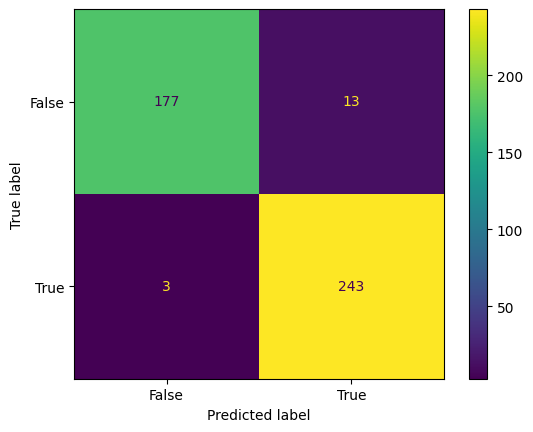

In [45]:
# Confusion matrix
cm = confusion_matrix(tokenized_test["label"], predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["False", "True"])
disp.plot()

## Load the best model from local directory

In [46]:
saved_dir = "modernbert-guardrail/fold_4/checkpoint-96"
ft_model = AutoModelForSequenceClassification.from_pretrained(saved_dir) #num_labels=num_labels, label2id = label2id, id2label=id2label)
ft_tokenizer = AutoTokenizer.from_pretrained(saved_dir)

In [47]:
nlp = pipeline("text-classification", model=ft_model, tokenizer=ft_tokenizer)

text = "What is the shipping rate of delivering an item"
print(nlp(text))
# [{'label': 'positive', 'score': 0.987...}]

Device set to use cuda:0
/home/deeplyneuralicious/Project/bert-guardrail/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


[{'label': 1, 'score': 0.677493155002594}]


## Train the model with full dataset

In [29]:
tokenized_full_ds = hf_train_ds.map(tokenize_func,batched=True,remove_columns=["text"])
tokenized_full_ds

Map:   0%|          | 0/1742 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 1742
})

In [ ]:
train_results=[]

config = AutoConfig.from_pretrained(model_id, 
                                    num_labels=num_labels, 
                                    label2id = label2id, 
                                    id2label=id2label, 
                                    classifier_dropout=0.2) # dropout for regularization to avoid overfitting

# Reinitialize new model to train
model = AutoModelForSequenceClassification.from_pretrained(model_id, config=config)

# Freeze all layers except the classifier
for param in model.parameters():
    param.requires_grad = False

# Keep only the classification head trainable
for param in model.classifier.parameters():
    param.requires_grad = True


print(f"----------Training started----------")

# Define training args
training_args = TrainingArguments(
    output_dir= f"./modernbert-guardrail/final",
    per_device_train_batch_size=128,
    per_device_eval_batch_size=64,
    learning_rate=1e-3,
    num_train_epochs=5,
    fp16=True, # bfloat16 training 
    optim="adamw_torch", # improved optimizer
    lr_scheduler_type="linear",
    warmup_ratio=0.1, # gradually ramps up the learning rate for the first 10% of training steps
    weight_decay=0.01, # L2 penalty to discourage large weights
    logging_dir=f"./logs/final", 
    logging_strategy="steps",
    logging_steps=6,
    logging_first_step=True,
    eval_strategy="no",
    save_strategy="no",
    save_total_limit=2,
    load_best_model_at_end=False,
    metric_for_best_model="f1",
    report_to="tensorboard",
    # push_to_hub=True,
    # hub_strategy="every_save",
    # hub_token=hf_token,

)

# Create a Trainer instance
trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    args=training_args,
    train_dataset=tokenized_full_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    # callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Dont need callback as no eval dataset for training full dataset
)

trainer.train()

print(f"\nEvaluation for bert model")
train_metrics = trainer.evaluate(eval_dataset=tokenized_full_ds)
train_results.append(train_metrics)

print(f"Training score: {train_metrics}\n") # evaluate metrics on training dataset aside from evaluating the training loss


Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


----------Training started----------


Step,Training Loss
1,0.688900
6,0.666600
12,0.529400
18,0.365900
24,0.287400
30,0.257000
36,0.225200
42,0.194200
48,0.181400
54,0.172700



Evaluation for bert model


Training score: {'eval_loss': 0.15962588787078857, 'eval_f1': 0.9550840128845266, 'eval_precision': 0.9556932217394919, 'eval_recall': 0.9552238805970149, 'eval_accuracy': 0.9552238805970149, 'eval_runtime': 50.0059, 'eval_samples_per_second': 34.836, 'eval_steps_per_second': 0.56, 'epoch': 5.0}



In [34]:
trainer.save_model("./modernbert-guardrail/final")
tokenizer.save_pretrained("./modernbert-guardrail/final")

('./modernbert-guardrail/final/tokenizer_config.json',
 './modernbert-guardrail/final/special_tokens_map.json',
 './modernbert-guardrail/final/tokenizer.json')

## Export to ONNX for deployment

In [4]:
saved_dir = "./modernbert-guardrail/final"

# Load the fine-tuned model
ft_model = AutoModelForSequenceClassification.from_pretrained(saved_dir)
ft_tokenizer = AutoTokenizer.from_pretrained(saved_dir)

# Define dummy input for tracing the ONNX graph
dummy_text = "What is the steps for returning items?"
dummy_input = ft_tokenizer(dummy_text, return_tensors="pt")
dummy_input

{'input_ids': tensor([[50281,  1276,   310,   253,  5018,   323, 10884,  4957,    32, 50282]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [5]:
output = ft_model(**dummy_input)
output

SequenceClassifierOutput(loss=None, logits=tensor([[-1.1977,  0.9063]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [10]:
# Export to ONNX
torch.onnx.export(
    ft_model,
    (dummy_input["input_ids"], dummy_input["attention_mask"]),
    "./onnx/modernbert_guardrail.onnx",
    export_params = True,
    input_names=["input_ids","attention_mask"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch_size", 1: "sequence_length"},
        "attention_mask": {0: "batch_size", 1: "sequence_length"},
        "logits": {0: "batch_size"},
    },
    opset_version=16,
    verbose=False
)

print("Model exported to ONNX format")

Model exported to ONNX format


## Run Inference the ONNX model

In [13]:
import onnx

onnx_dir = "./onnx/modernbert_guardrail.onnx"
onnx_model = onnx.load(onnx_dir)
onnx.checker.check_model(onnx_model)

In [14]:
import onnxruntime as ort
# List available providers
print(ort.get_available_providers())

['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [ ]:
# For logging
session_options = ort.SessionOptions()
session_options.log_severity_level = 1  # 0 = VERBOSE, 1 = INFO, 2 = WARNING

In [ ]:
# Create a GPU session
session = ort.InferenceSession(onnx_dir,
                               # sess_options=session_options, 
                               providers=["CUDAExecutionProvider", "CPUExecutionProvider"]  # fallback to CPU if no GPU
                               ) 

test_input = {"input_ids": dummy_input["input_ids"].numpy(),
                    "attention_mask": dummy_input["attention_mask"].numpy()}
outputs = session.run(None, test_input)

In [21]:
logits = outputs[0]
pred = np.argmax(logits,axis=-1)
print("Predicted label:", pred)

Predicted label: [1]
